In [ ]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import editdistance

# ==========================================
# 1. KONFIGURASI
# ==========================================
class Config:
    BASE_PATH = "E:/SUGENG/dataset/Full_Dataset"
    DATA_SETS = ["Set1", "Set2", "Set3"]
    CHECKPOINT_DIR = "checkpoints_naskh_2"
    OUTPUT_DIR = "paper_results_2"
    # Eksperimen 1: Resolusi rendah
    IMG_HEIGHT = 32
    # Eksperimen 2: Resolusi tinggi
    #IMG_HEIGHT = 96
    BATCH_SIZE = 4          
    ACCUMULATION_STEPS = 8  
    EPOCHS = 50
    LR = 0.0005 
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

os.makedirs(Config.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)

# ==========================================
# 2. KAMUS KARAKTER & METRIK
# ==========================================
class CharMap:
    def __init__(self, df):
        chars = set()
        for label in df['label'].astype(str):
            chars.update(list(label))
        self.char_to_id = {char: idx + 1 for idx, char in enumerate(sorted(list(chars)))}
        self.char_to_id['[blank]'] = 0
        self.id_to_char = {idx: char for char, idx in self.char_to_id.items()}
        self.num_classes = len(self.char_to_id)

    def encode(self, text):
        return [self.char_to_id[c] for c in text if c in self.char_to_id]

    def decode(self, ids):
        tokens = []
        for i in range(len(ids)):
            if ids[i] != 0 and (i == 0 or ids[i] != ids[i-1]):
                if ids[i] in self.id_to_char:
                    tokens.append(self.id_to_char[ids[i]])
        return "".join(tokens)

def calculate_metrics(gt_text, pred_text):
    cer_dist = editdistance.eval(gt_text, pred_text)
    cer = cer_dist / max(1, len(gt_text))
    gt_words = gt_text.split()
    pred_words = pred_text.split()
    wer_dist = editdistance.eval(gt_words, pred_words)
    wer = wer_dist / max(1, len(gt_words))
    return cer, wer

# ==========================================
# 3. DATASET & LOADING
# ==========================================
def load_naskh_data():
    all_dfs = []
    for s in Config.DATA_SETS:
        csv_path = os.path.join(Config.BASE_PATH, s, "labels.csv")
        img_dir = os.path.join(Config.BASE_PATH, s, "images")
        if not os.path.exists(csv_path): continue
        df = pd.read_csv(csv_path, header=None, names=['id', 'filename', 'class', 'label'])
        df = df[df['class'] == 'Naskh'].dropna()
        df['full_path'] = df['filename'].apply(lambda x: os.path.join(img_dir, x))
        all_dfs.append(df)
    return pd.concat(all_dfs, ignore_index=True)

class NaskhDataset(Dataset):
    def __init__(self, df, char_map):
        self.df = df.reset_index(drop=True)
        self.char_map = char_map

    def __len__(self): 
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['full_path'], cv2.IMREAD_GRAYSCALE)
        if img is None: 
            return None
        
        # Flip horizontal untuk RTL (Right-to-Left)
        img = cv2.flip(img, 1)  
        
        h, w = img.shape
        new_w = int((Config.IMG_HEIGHT / h) * w)
        new_w = max(1000, (new_w // 4) * 4) 
        img = cv2.resize(img, (new_w, Config.IMG_HEIGHT))
        img = (img.astype(np.float32) / 127.5) - 1.0
        
        return torch.FloatTensor(img).unsqueeze(0), self.char_map.encode(str(row['label'])), str(row['label'])

def collate_fn(batch):
    batch = [b for b in batch if b is not None and len(b[1]) > 0]
    if not batch: 
        return None
    
    imgs, labels, raws = zip(*batch)
    max_w = max([img.shape[2] for img in imgs])
    padded_imgs = [nn.functional.pad(img, (0, max_w - img.shape[2], 0, 0), value=1.0) for img in imgs]
    
    return torch.stack(padded_imgs), torch.IntTensor([i for l in labels for i in l]), torch.IntTensor([len(l) for l in labels]), raws

# ==========================================
# 4. ARSITEKTUR CRNN
# ==========================================
class CRNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2, 2),        # 64 -> 32
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2, 2),       # 32 -> 16
            nn.Conv2d(128, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d((2, 1), (2, 1)),                                    # 16 -> 8
            nn.Conv2d(256, 512, 3, 1, 1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d((2, 1), (2, 1)),                                    # 8 -> 4
            nn.Conv2d(512, 512, 2, 1, (0, 1)), nn.BatchNorm2d(512), nn.ReLU() # 4 -> 1
        )
        self.rnn = nn.LSTM(512, 256, bidirectional=True, batch_first=True, num_layers=2)
        self.linear = nn.Linear(512, num_classes)
        
    def forward(self, x):
        x = self.cnn(x) 
        b, c, h, w = x.size()
        if h > 1: 
            x = nn.functional.adaptive_avg_pool2d(x, (1, w))
        x = x.squeeze(2).permute(0, 2, 1) 
        seq_len = x.size(1)
        x, _ = self.rnn(x)
        x = self.linear(x)
        return x.permute(1, 0, 2), seq_len

# ==========================================
# 5. TRAINING & VALIDATION LOOP (DIPERBAIKI)
# ==========================================
def train():
    print("=" * 60)
    print("MEMUAT DATA...")
    print("=" * 60)
    
    df = load_naskh_data()
    char_map = CharMap(df)
    
    print(f"Total data: {len(df)} samples")
    print(f"Jumlah karakter: {char_map.num_classes}")
    print(f"Device: {Config.DEVICE}")
    print("=" * 60)
    
    # Split data 90% train, 10% validation
    train_df = df.sample(frac=0.9, random_state=42)
    val_df = df.drop(train_df.index)
    
    print(f"Train data: {len(train_df)} samples")
    print(f"Val data: {len(val_df)} samples")
    print("=" * 60)
    
    train_loader = DataLoader(NaskhDataset(train_df, char_map), 
                              Config.BATCH_SIZE, shuffle=True, 
                              collate_fn=collate_fn, drop_last=True)
    
    val_loader = DataLoader(NaskhDataset(val_df, char_map), 
                            Config.BATCH_SIZE, shuffle=False, 
                            collate_fn=collate_fn, drop_last=True)

    model = CRNN(char_map.num_classes).to(Config.DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=Config.LR, weight_decay=1e-4)
    criterion = nn.CTCLoss(blank=0, zero_infinity=True)
    scaler = GradScaler()

    history = {'train_loss': [], 'val_loss': [], 'val_cer': [], 'val_wer': []}
    best_val_loss = float('inf')

    for epoch in range(Config.EPOCHS):
        # ==========================================
        # TRAINING PHASE
        # ==========================================
        model.train()
        train_loss = 0
        num_train_batches = 0
        optimizer.zero_grad()
        scaled_loss_accumulated = False
        
        # Simpan sample terakhir untuk ditampilkan
        last_train_batch = None
        last_train_logits = None

        for i, batch in enumerate(train_loader):
            if batch is None: 
                continue
            
            imgs, targets, tg_lens, raws = batch
            last_train_batch = (imgs, targets, tg_lens, raws)
            
            imgs, targets = imgs.to(Config.DEVICE), targets.to(Config.DEVICE)
            
            with autocast():
                logits, seq_len = model(imgs)
                last_train_logits = logits  # Simpan logits untuk prediksi nanti
                input_lengths = torch.full((imgs.size(0),), seq_len, dtype=torch.long).to(Config.DEVICE)
                loss = criterion(logits.log_softmax(2), targets, input_lengths, tg_lens)

            if not torch.isnan(loss) and not torch.isinf(loss):
                scaler.scale(loss / Config.ACCUMULATION_STEPS).backward()
                train_loss += loss.item()
                num_train_batches += 1
                scaled_loss_accumulated = True

            if (i + 1) % Config.ACCUMULATION_STEPS == 0 and scaled_loss_accumulated:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                scaled_loss_accumulated = False

        avg_train_loss = train_loss / max(1, num_train_batches)

        # ==========================================
        # VALIDATION PHASE
        # ==========================================
        model.eval()
        val_loss = 0
        num_val_batches = 0
        total_cer = 0
        total_wer = 0
        total_samples = 0
        
        # Simpan sample validasi untuk ditampilkan
        val_sample_gt = None
        val_sample_pred = None
        
        with torch.no_grad():
            for batch in val_loader:
                if batch is None: 
                    continue
                
                v_imgs, v_targets, v_tg_lens, v_raws = batch
                v_imgs = v_imgs.to(Config.DEVICE)
                
                v_logits, v_seq_len = model(v_imgs)
                v_input_lengths = torch.full((v_imgs.size(0),), v_seq_len, dtype=torch.long).to(Config.DEVICE)
                
                loss = criterion(v_logits.log_softmax(2), v_targets.to(Config.DEVICE), 
                               v_input_lengths, v_tg_lens)
                
                if not torch.isnan(loss) and not torch.isinf(loss):
                    val_loss += loss.item()
                    num_val_batches += 1
                
                # Hitung CER dan WER
                _, p_idx = v_logits.max(2)  # [seq_len, batch_size]
                
                for b in range(v_imgs.size(0)):
                    pred_ids = p_idx[:, b].cpu().tolist()
                    pred_text = char_map.decode(pred_ids)
                    gt_text = v_raws[b]
                    
                    # Simpan sample validasi pertama untuk ditampilkan
                    if total_samples == 0:
                        val_sample_gt = gt_text
                        val_sample_pred = pred_text
                    
                    cer, wer = calculate_metrics(gt_text, pred_text)
                    total_cer += cer
                    total_wer += wer
                    total_samples += 1

        avg_val_loss = val_loss / max(1, num_val_batches)
        avg_cer = total_cer / max(1, total_samples)
        avg_wer = total_wer / max(1, total_samples)

        # Simpan history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_cer'].append(avg_cer)
        history['val_wer'].append(avg_wer)

        # ==========================================
        # DISPLAY RESULTS (DIPERBAIKI)
        # ==========================================
        print(f"\n{'='*60}")
        print(f"EPOCH {epoch+1}/{Config.EPOCHS}")
        print(f"{'='*60}")
        print(f"Train Loss: {avg_train_loss:.6f}")
        print(f"Val Loss:   {avg_val_loss:.6f}")
        print(f"Val CER:    {avg_cer*100:.2f}%")
        print(f"Val WER:    {avg_wer*100:.2f}%")
        
        # Tampilkan prediksi dari TRAINING (batch terakhir)
        if last_train_batch is not None and last_train_logits is not None:
            _, train_p_idx = last_train_logits.max(2)
            train_sample_gt = last_train_batch[3][0]  # Ground truth sample pertama
            train_sample_pred_ids = train_p_idx[:, 0].cpu().tolist()
            train_sample_pred_text = char_map.decode(train_sample_pred_ids)
            
            print(f"\n--- SAMPLE PREDIKSI (TRAIN) ---")
            print(f"GT  : {train_sample_gt[:100]}")
            print(f"Pred: {train_sample_pred_text[:100]}")
        
        # Tampilkan prediksi dari VALIDASI
        if val_sample_gt is not None:
            print(f"\n--- SAMPLE PREDIKSI (VALIDASI) ---")
            print(f"GT  : {val_sample_gt[:100]}")
            print(f"Pred: {val_sample_pred[:100] if val_sample_pred else '[KOSONG]'}")
        
        # Save checkpoint berdasarkan best validation loss
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            checkpoint = {
                'epoch': epoch + 1,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'char_to_id': char_map.char_to_id,
                'id_to_char': char_map.id_to_char,
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss,
                'val_cer': avg_cer,
                'val_wer': avg_wer
            }
            torch.save(checkpoint, os.path.join(Config.CHECKPOINT_DIR, "best_model.pth"))
            print(f"\n*** Best model saved! (Val Loss: {avg_val_loss:.6f}) ***")
        
        # Save checkpoint periodik
        if (epoch + 1) % 10 == 0:
            torch.save(checkpoint, os.path.join(Config.CHECKPOINT_DIR, f"checkpoint_epoch_{epoch+1}.pth"))
            print(f"Checkpoint saved at epoch {epoch+1}")

    # ==========================================
    # SAVE RESULTS
    # ==========================================
    print("\n" + "="*60)
    print("TRAINING SELESAI!")
    print("="*60)
    
    # Save history ke CSV
    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(Config.OUTPUT_DIR, "training_history.csv"), index=False)
    print(f"Training history saved to {Config.OUTPUT_DIR}/training_history.csv")
    
    # Plot dan save grafik
    plot_training_results(history)
    
    # Save final model
    final_checkpoint = {
        'model_state': model.state_dict(),
        'char_to_id': char_map.char_to_id,
        'id_to_char': char_map.id_to_char,
        'history': history
    }
    torch.save(final_checkpoint, os.path.join(Config.CHECKPOINT_DIR, "final_model.pth"))
    print(f"Final model saved to {Config.CHECKPOINT_DIR}/final_model.pth")

def plot_training_results(history):
    """Plot training metrics"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Plot Loss
    axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
    axes[0].plot(history['val_loss'], label='Val Loss', color='red')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Plot CER
    axes[1].plot(history['val_cer'], label='CER', color='green')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('CER')
    axes[1].set_title('Character Error Rate')
    axes[1].legend()
    axes[1].grid(True)
    
    # Plot WER
    axes[2].plot(history['val_wer'], label='WER', color='orange')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('WER')
    axes[2].set_title('Word Error Rate')
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(Config.OUTPUT_DIR, 'training_curves.png'), dpi=150)
    plt.show()
    print(f"Training curves saved to {Config.OUTPUT_DIR}/training_curves.png")

# ==========================================
# 6. FUNGSI TESTING / INFERENCE
# ==========================================
def test_model(model_path, test_samples=None):
    """
    Fungsi untuk testing model terlatih
    
    Args:
        model_path: path ke checkpoint model
        test_samples: list of tuples (image_path, ground_truth) atau None untuk test random
    """
    print("\n" + "="*60)
    print("TESTING MODEL")
    print("="*60)
    
    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=Config.DEVICE)
    
    # Rebuild charmap
    char_map = CharMap(pd.DataFrame())  # Temporary
    char_map.char_to_id = checkpoint['char_to_id']
    char_map.id_to_char = checkpoint['id_to_char']
    char_map.num_classes = len(char_map.char_to_id)
    
    # Load model
    model = CRNN(char_map.num_classes).to(Config.DEVICE)
    model.load_state_dict(checkpoint['model_state'])
    model.eval()
    
    print(f"Model loaded from {model_path}")
    print(f"Model trained at epoch {checkpoint.get('epoch', 'unknown')}")
    print(f"Validation loss: {checkpoint.get('val_loss', 'unknown')}")
    
    if test_samples is None:
        # Load random test samples dari dataset
        df = load_naskh_data()
        test_df = df.sample(min(10, len(df)), random_state=123)
        test_samples = [(row['full_path'], row['label']) for _, row in test_df.iterrows()]
    
    results = []
    for img_path, gt_text in test_samples:
        # Load and preprocess image
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        
        img = cv2.flip(img, 1)
        h, w = img.shape
        new_w = int((Config.IMG_HEIGHT / h) * w)
        new_w = max(1000, (new_w // 4) * 4)
        img = cv2.resize(img, (new_w, Config.IMG_HEIGHT))
        img = (img.astype(np.float32) / 127.5) - 1.0
        img_tensor = torch.FloatTensor(img).unsqueeze(0).unsqueeze(0).to(Config.DEVICE)
        
        # Inference
        with torch.no_grad():
            logits, _ = model(img_tensor)
            _, pred_ids = logits.max(2)
            pred_text = char_map.decode(pred_ids[:, 0].cpu().tolist())
        
        cer, wer = calculate_metrics(gt_text, pred_text)
        results.append({
            'image': os.path.basename(img_path),
            'ground_truth': gt_text,
            'prediction': pred_text,
            'cer': cer,
            'wer': wer
        })
        
        print(f"\n--- {os.path.basename(img_path)} ---")
        print(f"GT  : {gt_text}")
        print(f"Pred: {pred_text}")
        print(f"CER : {cer*100:.2f}%")
        print(f"WER : {wer*100:.2f}%")
    
    # Summary
    avg_cer = np.mean([r['cer'] for r in results])
    avg_wer = np.mean([r['wer'] for r in results])
    print(f"\n{'='*60}")
    print(f"TESTING SUMMARY")
    print(f"{'='*60}")
    print(f"Total samples: {len(results)}")
    print(f"Average CER: {avg_cer*100:.2f}%")
    print(f"Average WER: {avg_wer*100:.2f}%")
    
    # Save results
    results_df = pd.DataFrame(results)
    results_df.to_csv(os.path.join(Config.OUTPUT_DIR, "test_results.csv"), index=False)
    
    return results

# ==========================================
# 7. MAIN
# ==========================================
if __name__ == "__main__":
    # Training
    train()
    
    # Optional: Test model terbaik setelah training
    best_model_path = os.path.join(Config.CHECKPOINT_DIR, "best_model.pth")
    if os.path.exists(best_model_path):
        print("\n" + "="*60)
        print("MELAKUKAN TESTING DENGAN BEST MODEL...")
        print("="*60)
        test_model(best_model_path)

In [1]:
# Program Untuk Analisa lebih Lengkap, Jurnal Penagaruh Resolusi Citra dan Akumulasi Gradien


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Program Files\Python312\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Program Files\Python312\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Program Files\Python312\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File "C:\Program Files\Python312\Lib\s

MEMUAT DATA...
Total data: 3735 samples
Jumlah karakter: 40
Train: 3362, Val: 373

Menjalankan: Baseline
  - Tinggi: 32px
  - Min Width: 256px
  - Horizontal Flip: False
  - Gradient Accumulation: 1
Epoch 1: Train Loss=3.0941, Val Loss=0.0000, CER=100.00%
Epoch 2: Train Loss=2.9767, Val Loss=0.0000, CER=100.00%
Epoch 3: Train Loss=2.9544, Val Loss=0.0000, CER=100.00%
Epoch 4: Train Loss=2.9357, Val Loss=0.0000, CER=100.00%
Epoch 5: Train Loss=2.9163, Val Loss=0.0000, CER=100.00%
Epoch 6: Train Loss=2.8588, Val Loss=0.0000, CER=100.00%
Epoch 7: Train Loss=2.9027, Val Loss=0.0000, CER=100.00%
Epoch 8: Train Loss=2.8808, Val Loss=0.0000, CER=100.00%
Epoch 9: Train Loss=2.8454, Val Loss=0.0000, CER=100.00%
Epoch 10: Train Loss=2.8288, Val Loss=0.0000, CER=100.00%
Epoch 11: Train Loss=2.8692, Val Loss=0.0000, CER=100.00%
Epoch 12: Train Loss=2.8307, Val Loss=0.0000, CER=100.00%
Epoch 13: Train Loss=2.8628, Val Loss=0.0000, CER=100.00%
Epoch 14: Train Loss=2.8951, Val Loss=0.0000, CER=100.00

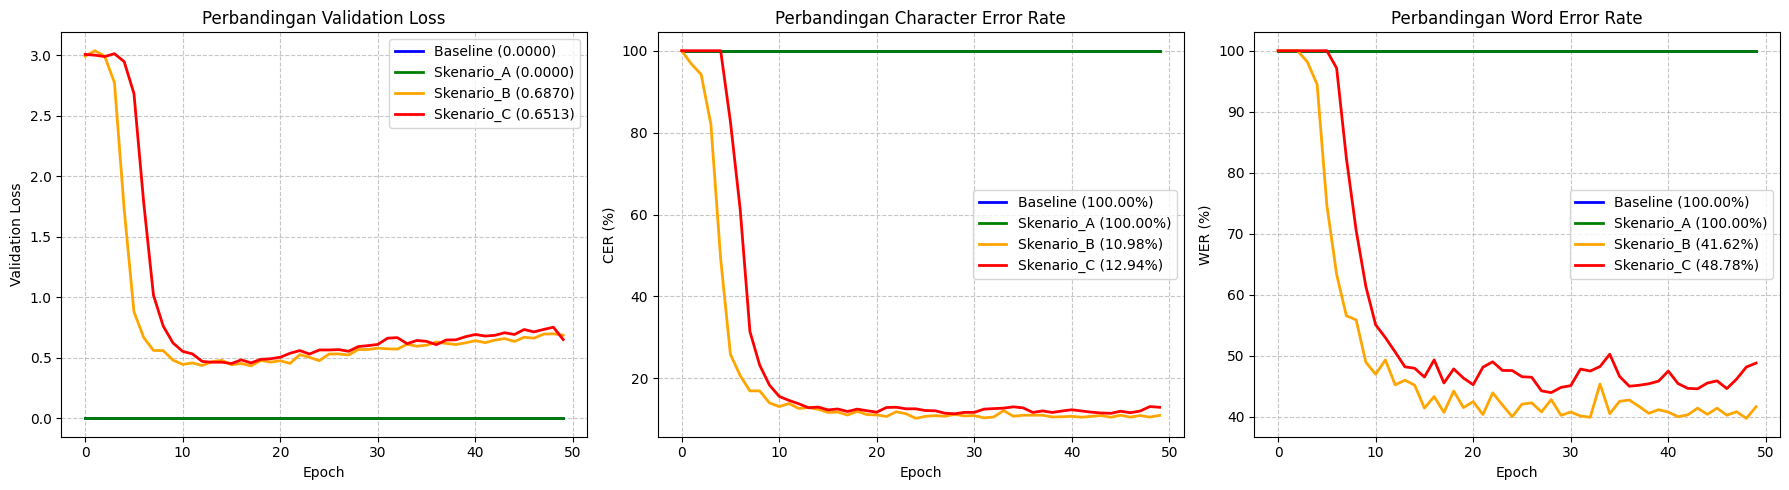

Grafik perbandingan disimpan di paper_results/scenario_comparison.png


In [1]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import editdistance
import json
from datetime import datetime

# ==========================================
# 1. KONFIGURASI DASAR
# ==========================================
class Config:
    BASE_PATH = "E:/SUGENG/dataset/Full_Dataset"
    DATA_SETS = ["Set1", "Set2", "Set3"]
    CHECKPOINT_DIR = "checkpoints_naskh"
    OUTPUT_DIR = "paper_results"
    BATCH_SIZE = 4          
    ACCUMULATION_STEPS = 8  
    EPOCHS = 50
    LR = 0.0005 
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # SKENARIO EKSPERIMEN (untuk Bab 3.1 & 3.2)
    SCENARIOS = [
        {'name': 'Baseline', 'height': 32, 'flip': False, 'min_width': 256, 'accum': 1},
        {'name': 'Skenario_A', 'height': 32, 'flip': True, 'min_width': 256, 'accum': 1},
        {'name': 'Skenario_B', 'height': 32, 'flip': True, 'min_width': 1000, 'accum': 1},
        {'name': 'Skenario_C', 'height': 32, 'flip': True, 'min_width': 1000, 'accum': 8},
    ]

os.makedirs(Config.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)

# ==========================================
# 2. KAMUS KARAKTER & METRIK
# ==========================================
class CharMap:
    def __init__(self, df=None):
        if df is not None and len(df) > 0:
            chars = set()
            for label in df['label'].astype(str):
                chars.update(list(label))
            self.char_to_id = {char: idx + 1 for idx, char in enumerate(sorted(list(chars)))}
            self.char_to_id['[blank]'] = 0
            self.id_to_char = {idx: char for char, idx in self.char_to_id.items()}
            self.num_classes = len(self.char_to_id)
        else:
            self.char_to_id = {}
            self.id_to_char = {}
            self.num_classes = 0

    def encode(self, text):
        return [self.char_to_id[c] for c in text if c in self.char_to_id]

    def decode(self, ids):
        tokens = []
        for i in range(len(ids)):
            if ids[i] != 0 and (i == 0 or ids[i] != ids[i-1]):
                if ids[i] in self.id_to_char:
                    tokens.append(self.id_to_char[ids[i]])
        return "".join(tokens)

def calculate_metrics(gt_text, pred_text):
    cer_dist = editdistance.eval(gt_text, pred_text)
    cer = cer_dist / max(1, len(gt_text))
    gt_words = gt_text.split()
    pred_words = pred_text.split()
    wer_dist = editdistance.eval(gt_words, pred_words)
    wer = wer_dist / max(1, len(gt_words))
    return cer, wer

# ==========================================
# 3. DATASET & LOADING
# ==========================================
def load_naskh_data():
    all_dfs = []
    for s in Config.DATA_SETS:
        csv_path = os.path.join(Config.BASE_PATH, s, "labels.csv")
        img_dir = os.path.join(Config.BASE_PATH, s, "images")
        if not os.path.exists(csv_path): continue
        df = pd.read_csv(csv_path, header=None, names=['id', 'filename', 'class', 'label'])
        df = df[df['class'] == 'Naskh'].dropna()
        df['full_path'] = df['filename'].apply(lambda x: os.path.join(img_dir, x))
        all_dfs.append(df)
    return pd.concat(all_dfs, ignore_index=True)

class NaskhDataset(Dataset):
    def __init__(self, df, char_map, img_height=32, min_width=256, flip=False):
        self.df = df.reset_index(drop=True)
        self.char_map = char_map
        self.img_height = img_height
        self.min_width = min_width
        self.flip = flip

    def __len__(self): 
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['full_path'], cv2.IMREAD_GRAYSCALE)
        if img is None: 
            return None
        
        # Flip horizontal jika diperlukan
        if self.flip:
            img = cv2.flip(img, 1)  
        
        h, w = img.shape
        new_w = int((self.img_height / h) * w)
        new_w = max(self.min_width, (new_w // 4) * 4) 
        img = cv2.resize(img, (new_w, self.img_height))
        img = (img.astype(np.float32) / 127.5) - 1.0
        
        return torch.FloatTensor(img).unsqueeze(0), self.char_map.encode(str(row['label'])), str(row['label'])

def collate_fn(batch):
    batch = [b for b in batch if b is not None and len(b[1]) > 0]
    if not batch: 
        return None
    
    imgs, labels, raws = zip(*batch)
    max_w = max([img.shape[2] for img in imgs])
    padded_imgs = [nn.functional.pad(img, (0, max_w - img.shape[2], 0, 0), value=1.0) for img in imgs]
    
    return torch.stack(padded_imgs), torch.IntTensor([i for l in labels for i in l]), torch.IntTensor([len(l) for l in labels]), raws

# ==========================================
# 4. ARSITEKTUR CRNN
# ==========================================
class CRNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2, 2),        # 64 -> 32
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2, 2),       # 32 -> 16
            nn.Conv2d(128, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d((2, 1), (2, 1)),                                    # 16 -> 8
            nn.Conv2d(256, 512, 3, 1, 1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d((2, 1), (2, 1)),                                    # 8 -> 4
            nn.Conv2d(512, 512, 2, 1, (0, 1)), nn.BatchNorm2d(512), nn.ReLU() # 4 -> 1
        )
        self.rnn = nn.LSTM(512, 256, bidirectional=True, batch_first=True, num_layers=2)
        self.linear = nn.Linear(512, num_classes)
        
    def forward(self, x):
        x = self.cnn(x) 
        b, c, h, w = x.size()
        if h > 1: 
            x = nn.functional.adaptive_avg_pool2d(x, (1, w))
        x = x.squeeze(2).permute(0, 2, 1) 
        seq_len = x.size(1)
        x, _ = self.rnn(x)
        x = self.linear(x)
        return x.permute(1, 0, 2), seq_len

# ==========================================
# 5. TRAINING UNTUK SATU SKENARIO
# ==========================================
def train_scenario(scenario_config, train_df, val_df, char_map):
    """Training untuk satu skenario eksperimen"""
    
    print(f"\n{'='*60}")
    print(f"Menjalankan: {scenario_config['name']}")
    print(f"  - Tinggi: {scenario_config['height']}px")
    print(f"  - Min Width: {scenario_config['min_width']}px")
    print(f"  - Horizontal Flip: {scenario_config['flip']}")
    print(f"  - Gradient Accumulation: {scenario_config['accum']}")
    print(f"{'='*60}")
    
    # Dataset dengan konfigurasi spesifik
    train_dataset = NaskhDataset(
        train_df, char_map,
        img_height=scenario_config['height'],
        min_width=scenario_config['min_width'],
        flip=scenario_config['flip']
    )
    val_dataset = NaskhDataset(
        val_df, char_map,
        img_height=scenario_config['height'],
        min_width=scenario_config['min_width'],
        flip=scenario_config['flip']
    )
    
    train_loader = DataLoader(train_dataset, Config.BATCH_SIZE, shuffle=True, 
                              collate_fn=collate_fn, drop_last=True)
    val_loader = DataLoader(val_dataset, Config.BATCH_SIZE, shuffle=False, 
                            collate_fn=collate_fn, drop_last=True)
    
    model = CRNN(char_map.num_classes).to(Config.DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=Config.LR, weight_decay=1e-4)
    criterion = nn.CTCLoss(blank=0, zero_infinity=True)
    scaler = GradScaler()
    
    history = {'train_loss': [], 'val_loss': [], 'val_cer': [], 'val_wer': []}
    best_val_loss = float('inf')
    
    for epoch in range(Config.EPOCHS):
        # ===== TRAINING =====
        model.train()
        train_loss = 0
        num_train_batches = 0
        optimizer.zero_grad()
        scaled_loss_accumulated = False
        
        for i, batch in enumerate(train_loader):
            if batch is None: continue
            
            imgs, targets, tg_lens, raws = batch
            imgs, targets = imgs.to(Config.DEVICE), targets.to(Config.DEVICE)
            
            with autocast():
                logits, seq_len = model(imgs)
                input_lengths = torch.full((imgs.size(0),), seq_len, dtype=torch.long).to(Config.DEVICE)
                loss = criterion(logits.log_softmax(2), targets, input_lengths, tg_lens)
            
            if not torch.isnan(loss) and not torch.isinf(loss):
                scaler.scale(loss / scenario_config['accum']).backward()
                train_loss += loss.item()
                num_train_batches += 1
                scaled_loss_accumulated = True
            
            if (i + 1) % scenario_config['accum'] == 0 and scaled_loss_accumulated:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                scaled_loss_accumulated = False
        
        avg_train_loss = train_loss / max(1, num_train_batches)
        
        # ===== VALIDASI =====
        model.eval()
        val_loss = 0
        num_val_batches = 0
        total_cer = 0
        total_wer = 0
        total_samples = 0
        
        with torch.no_grad():
            for batch in val_loader:
                if batch is None: continue
                
                v_imgs, v_targets, v_tg_lens, v_raws = batch
                v_imgs = v_imgs.to(Config.DEVICE)
                
                v_logits, v_seq_len = model(v_imgs)
                v_input_lengths = torch.full((v_imgs.size(0),), v_seq_len, dtype=torch.long).to(Config.DEVICE)
                
                loss = criterion(v_logits.log_softmax(2), v_targets.to(Config.DEVICE), 
                               v_input_lengths, v_tg_lens)
                
                if not torch.isnan(loss) and not torch.isinf(loss):
                    val_loss += loss.item()
                    num_val_batches += 1
                
                _, p_idx = v_logits.max(2)
                for b in range(v_imgs.size(0)):
                    pred_ids = p_idx[:, b].cpu().tolist()
                    pred_text = char_map.decode(pred_ids)
                    gt_text = v_raws[b]
                    cer, wer = calculate_metrics(gt_text, pred_text)
                    total_cer += cer
                    total_wer += wer
                    total_samples += 1
        
        avg_val_loss = val_loss / max(1, num_val_batches)
        avg_cer = total_cer / max(1, total_samples)
        avg_wer = total_wer / max(1, total_samples)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_cer'].append(avg_cer)
        history['val_wer'].append(avg_wer)
        
        print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, CER={avg_cer*100:.2f}%")
        
        # Save best model untuk skenario ini
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            checkpoint_dir = os.path.join(Config.CHECKPOINT_DIR, scenario_config['name'])
            os.makedirs(checkpoint_dir, exist_ok=True)
            torch.save({
                'model_state': model.state_dict(),
                'char_to_id': char_map.char_to_id,
                'id_to_char': char_map.id_to_char,
                'history': history,
                'config': scenario_config
            }, os.path.join(checkpoint_dir, "best_model.pth"))
    
    # Simpan history ke CSV
    history_df = pd.DataFrame(history)
    output_dir = os.path.join(Config.OUTPUT_DIR, scenario_config['name'])
    os.makedirs(output_dir, exist_ok=True)
    history_df.to_csv(os.path.join(output_dir, "history.csv"), index=False)
    
    # Hasil akhir
    return {
        'name': scenario_config['name'],
        'final_val_loss': history['val_loss'][-1] if history['val_loss'] else None,
        'final_val_cer': history['val_cer'][-1] if history['val_cer'] else None,
        'final_val_wer': history['val_wer'][-1] if history['val_wer'] else None,
        'history': history
    }

# ==========================================
# 6. MAIN: JALANKAN 4 SKENARIO
# ==========================================
def run_all_scenarios():
    print("=" * 60)
    print("MEMUAT DATA...")
    print("=" * 60)
    
    df = load_naskh_data()
    char_map = CharMap(df)
    
    print(f"Total data: {len(df)} samples")
    print(f"Jumlah karakter: {char_map.num_classes}")
    
    # Split data 90% train, 10% validation
    train_df = df.sample(frac=0.9, random_state=42)
    val_df = df.drop(train_df.index)
    
    print(f"Train: {len(train_df)}, Val: {len(val_df)}")
    print("=" * 60)
    
    # Jalankan semua skenario
    all_results = []
    for scenario in Config.SCENARIOS:
        result = train_scenario(scenario, train_df, val_df, char_map)
        all_results.append(result)
    
    # ===== BUAT TABEL PERBANDINGAN (untuk Bab 3.2) =====
    print("\n" + "=" * 60)
    print("RINGKASAN HASIL EKSPERIMEN")
    print("=" * 60)
    print(f"{'Skenario':<15} {'Val Loss':<12} {'CER (%)':<12} {'WER (%)':<12}")
    print("-" * 60)
    
    comparison_data = []
    for r in all_results:
        print(f"{r['name']:<15} {r['final_val_loss']:.6f}   {r['final_val_cer']*100:.2f}        {r['final_val_wer']*100:.2f}")
        comparison_data.append({
            'Skenario': r['name'],
            'Val_Loss': r['final_val_loss'],
            'CER': r['final_val_cer'] * 100,
            'WER': r['final_val_wer'] * 100
        })
    
    # Simpan tabel perbandingan
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df.to_csv(os.path.join(Config.OUTPUT_DIR, "comparison_results.csv"), index=False)
    print(f"\nTabel perbandingan disimpan di {Config.OUTPUT_DIR}/comparison_results.csv")
    
    # ===== BUAT GRAFIK (untuk Gambar 1 di Bab 3.2) =====
    plot_comparison(all_results)

def plot_comparison(all_results):
    """Buat grafik perbandingan antar skenario"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    colors = ['blue', 'green', 'orange', 'red']
    
    # Plot 1: Val Loss
    for i, r in enumerate(all_results):
        axes[0].plot(r['history']['val_loss'], 
                     label=f"{r['name']} ({r['final_val_loss']:.4f})", 
                     color=colors[i], linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Validation Loss')
    axes[0].set_title('Perbandingan Validation Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    # Plot 2: CER
    for i, r in enumerate(all_results):
        axes[1].plot([c*100 for c in r['history']['val_cer']], 
                     label=f"{r['name']} ({r['final_val_cer']*100:.2f}%)", 
                     color=colors[i], linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('CER (%)')
    axes[1].set_title('Perbandingan Character Error Rate')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    # Plot 3: WER
    for i, r in enumerate(all_results):
        axes[2].plot([w*100 for w in r['history']['val_wer']], 
                     label=f"{r['name']} ({r['final_val_wer']*100:.2f}%)", 
                     color=colors[i], linewidth=2)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('WER (%)')
    axes[2].set_title('Perbandingan Word Error Rate')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(os.path.join(Config.OUTPUT_DIR, 'scenario_comparison.png'), dpi=300)
    plt.show()
    print(f"Grafik perbandingan disimpan di {Config.OUTPUT_DIR}/scenario_comparison.png")

# ==========================================
# 7. JALANKAN
# ==========================================
if __name__ == "__main__":
    run_all_scenarios()